---
title: Drzewa decyzyjne
jupyter:
  jupytext:
    text_representation:
      extension: .qmd
      format_name: quarto
      format_version: '1.0'
      jupytext_version: 1.17.3
  kernelspec:
    display_name: lista-4-projekt-grupowy-1 (3.14.3)
    language: python
    name: python3
---


In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve, roc_curve
from scripts.utils import load_preprocess_split, cost_score
from pathlib import Path

In [3]:
train_df, test_df = load_preprocess_split(Path("../data/neo_v2.csv"))

groups = train_df['id']

X_train = train_df.drop(columns=["id", "hazardous"])
y_train = train_df["hazardous"]
X_test = test_df.drop(columns=["id", "hazardous"])
y_test = test_df["hazardous"]

gkf = GroupKFold(n_splits=5)

In [4]:
tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [None, 3, 5, 10, 15, 20],
    'ccp_alpha': [0.0, 0.001, 0.01, 0.1],
    'class_weight': [None, 'balanced', {0: 1, 1: 5}, {0: 1, 1: 25}, {0: 1, 1: 50}]
}

In [5]:
grid_search = GridSearchCV(estimator=tree, param_grid=param_grid, cv=gkf, scoring=cost_score, n_jobs=-1)
grid_search.fit(X_train, y_train, groups=groups)
print("Najlepsze parametry:", grid_search.best_params_)

Najlepsze parametry: {'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: 25}, 'max_depth': None}


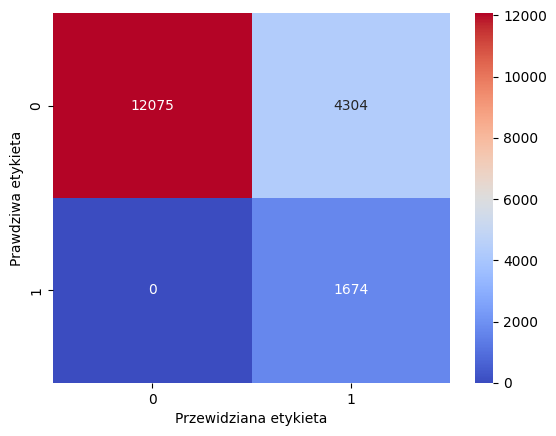

              precision    recall  f1-score   support

       False       1.00      0.74      0.85     16379
        True       0.28      1.00      0.44      1674

    accuracy                           0.76     18053
   macro avg       0.64      0.87      0.64     18053
weighted avg       0.93      0.76      0.81     18053



In [6]:
best_tree = grid_search.best_estimator_
y_pred = best_tree.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm')
plt.ylabel('Prawdziwa etykieta')
plt.xlabel('Przewidziana etykieta')
plt.show()

print(classification_report(y_test, y_pred))

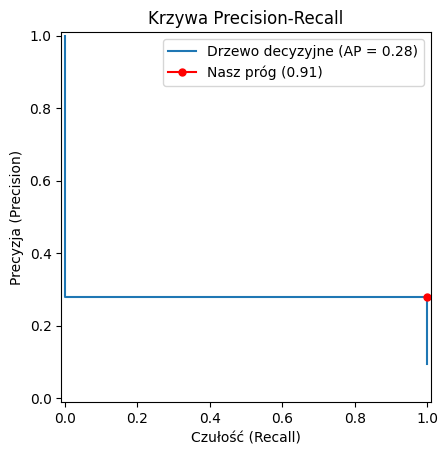

In [7]:
y_proba = best_tree.predict_proba(X_test)[:, 1]

PrecisionRecallDisplay.from_predictions(y_test, y_proba, name="Drzewo decyzyjne")

precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)
pr_thresholds_padded = np.append(pr_thresholds, pr_thresholds[-1]) 

recall_1 = np.where(recall == 1.0)[0]
best_thr = pr_thresholds_padded[recall_1[-1]]

idx_pr = np.argmin(np.abs(pr_thresholds_padded - best_thr))

plt.plot(recall[idx_pr], precision[idx_pr], marker="o", markersize=5, color="red", 
         label=f"Nasz próg ({best_thr:.2f})")

plt.title("Krzywa Precision-Recall")
plt.ylabel("Precyzja (Precision)")
plt.xlabel("Czułość (Recall)")
plt.legend()
plt.show()

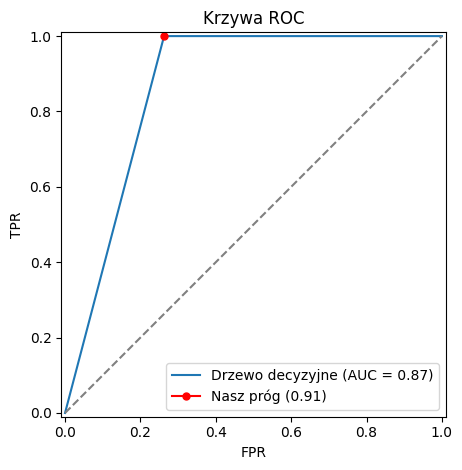

In [8]:
RocCurveDisplay.from_predictions(y_test, y_proba, name="Drzewo decyzyjne")

fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
idx_roc = np.argmin(np.abs(roc_thresholds - best_thr))

plt.plot(fpr[idx_roc], tpr[idx_roc], marker="o", markersize=5, color="red", 
         label=f"Nasz próg ({best_thr:.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle="--")

plt.title("Krzywa ROC")
plt.legend()
plt.tight_layout()
plt.ylabel("TPR")
plt.xlabel("FPR")
plt.show()

# Wnioski 

Najlepsze parametry: {'ccp_alpha': 0.01, 'class_weight': {0: 1, 1: 25}, 'max_depth': None}

Model poradził sobie ze 100% kwalifikacją wszystkich zagrożeń poprawnie, lecz widać, że ma problem z błędną klasyfikacją wyników negatywnych, 25% wyników negatywnych została sklasyfikowana jako zagrożenie, co bardzo obciąża finansowo agencje kosmiczne 